In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [3]:
# Optional: install keras-tuner in Kaggle if not already installed
!pip install -q keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.9 MB/s eta 0:00:00


Trial 3 Complete [00h 05m 16s]
val_accuracy: 0.625

Best val_accuracy So Far: 0.6875
Total elapsed time: 00h 15m 49s


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



Best hyperparameters for resnet_quick:
{'res_dense': 256, 'res_dropout': 0.5, 'res_lr': 0.001}

Training best CNN...
Epoch 1/6
163/163 ━━━━━━━━━━━━━━━━━━━━ 75s 438ms/step - accuracy: 0.8937 - loss: 0.2547 - val_accuracy: 0.9375 - val_loss: 0.3508
Epoch 2/6
163/163 ━━━━━━━━━━━━━━━━━━━━ 71s 436ms/step - accuracy: 0.9060 - loss: 0.2137 - val_accuracy: 0.9375 - val_loss: 0.4258
Epoch 3/6
163/163 ━━━━━━━━━━━━━━━━━━━━ 70s 429ms/step - accuracy: 0.9113 - loss: 0.1982 - val_accuracy: 0.8750 - val_loss: 0.4083

Training best LeNet-5...
Epoch 1/6
163/163 ━━━━━━━━━━━━━━━━━━━━ 74s 430ms/step - accuracy: 0.8734 - loss: 0.3047 - val_accuracy: 0.7500 - val_loss: 0.4968
Epoch 2/6
163/163 ━━━━━━━━━━━━━━━━━━━━ 70s 430ms/step - accuracy: 0.8729 - loss: 0.2908 - val_accuracy: 0.8750 - val_loss: 0.3722
Epoch 3/6
163/163 ━━━━━━━━━━━━━━━━━━━━ 71s 434ms/step - accuracy: 0.8802 - loss: 0.2905 - val_accuracy: 0.8750 - val_loss: 0.4495
Epoch 4/6
163/163 ━━━━━━━━━━━━━━━━━━━━ 70s 427ms/step - accuracy: 0.8823 - l

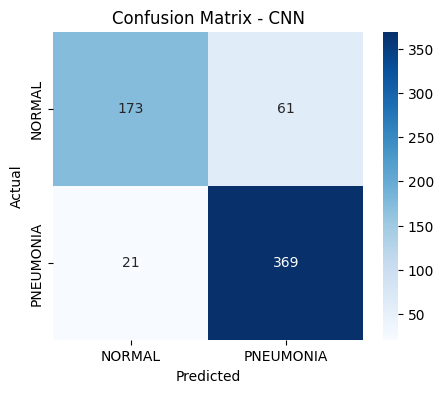

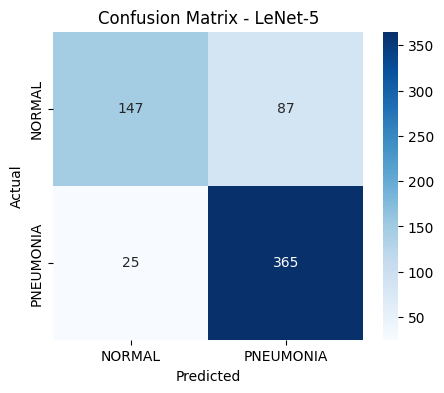

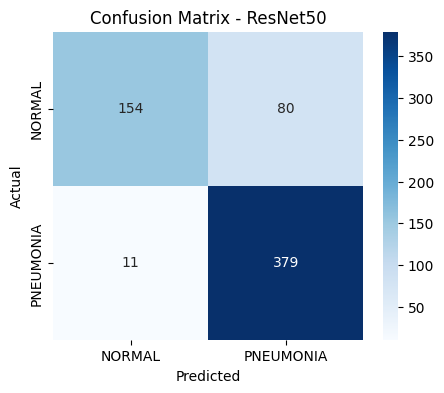

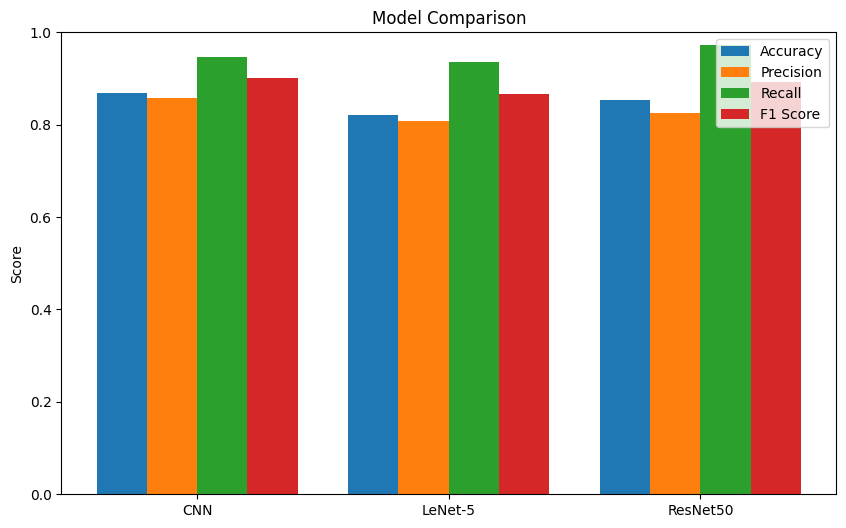

CNN: Accuracy=0.8686, Precision=0.8581, Recall=0.9462, F1=0.9000
LeNet-5: Accuracy=0.8205, Precision=0.8075, Recall=0.9359, F1=0.8670
ResNet50: Accuracy=0.8542, Precision=0.8257, Recall=0.9718, F1=0.8928


In [4]:
# =========================
# 1. IMPORTS
# =========================
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras_tuner as kt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.utils.class_weight import compute_class_weight

# =========================
# 2. PATHS
# =========================
root_path = "/kaggle/input/chest-xray-pneumonia/chest_xray"
train_path = os.path.join(root_path, "train")
val_path = os.path.join(root_path, "val")
test_path = os.path.join(root_path, "test")

IMG_SIZE = (160, 160)   # smaller = faster
BATCH_SIZE = 32
TUNE_EPOCHS = 4         # small for quick tuning
FINAL_EPOCHS = 6        # quick final train

# =========================
# 3. DATA GENERATORS
# =========================
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

val_generator = test_datagen.flow_from_directory(
    val_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

# =========================
# 4. CLASS WEIGHTS
# =========================
y_train = train_generator.classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)

# =========================
# 5. CALLBACKS
# =========================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

# =========================
# 6. QUICK TUNER BUILDERS
# =========================
def build_cnn(hp):
    model = models.Sequential([
        layers.Input(shape=(160, 160, 3)),
        layers.Conv2D(hp.Choice('cnn_filters1', [16, 32]), (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(hp.Choice('cnn_filters2', [32, 64]), (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(hp.Choice('cnn_filters3', [64, 128]), (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),

        layers.Flatten(),
        layers.Dense(hp.Choice('cnn_dense', [64, 128]), activation='relu'),
        layers.Dropout(hp.Choice('cnn_dropout', [0.3, 0.5])),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(hp.Choice('cnn_lr', [1e-3, 1e-4])),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


def build_lenet(hp):
    model = models.Sequential([
        layers.Input(shape=(160, 160, 3)),
        layers.Conv2D(hp.Choice('lenet_filters1', [6, 12]), (5,5), activation='tanh'),
        layers.AvgPool2D(2,2),

        layers.Conv2D(hp.Choice('lenet_filters2', [16, 32]), (5,5), activation='tanh'),
        layers.AvgPool2D(2,2),

        layers.Conv2D(hp.Choice('lenet_filters3', [60, 120]), (5,5), activation='tanh'),
        layers.Flatten(),
        layers.Dense(hp.Choice('lenet_dense', [84, 128]), activation='tanh'),
        layers.Dropout(hp.Choice('lenet_dropout', [0.2, 0.4])),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(hp.Choice('lenet_lr', [1e-3, 1e-4])),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


def build_resnet(hp):
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(160, 160, 3)
    )

    base_model.trainable = False  # stage 1 quick tuning

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(hp.Choice('res_dense', [128, 256]), activation='relu'),
        layers.Dropout(hp.Choice('res_dropout', [0.3, 0.5])),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(hp.Choice('res_lr', [1e-3, 1e-4])),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# =========================
# 7. QUICK HYPER-TUNING
# =========================
def quick_tune(build_fn, project_name):
    tuner = kt.RandomSearch(
        build_fn,
        objective='val_accuracy',
        max_trials=3,   # quick
        executions_per_trial=1,
        directory='quick_tuning',
        project_name=project_name,
        overwrite=True
    )

    tuner.search(
        train_generator,
        validation_data=val_generator,
        epochs=TUNE_EPOCHS,
        class_weight=class_weights,
        callbacks=[early_stop],
        verbose=1
    )

    best_model = tuner.get_best_models(1)[0]
    best_hp = tuner.get_best_hyperparameters(1)[0]
    print(f"\nBest hyperparameters for {project_name}:")
    print(best_hp.values)

    return best_model

# Tune all models
cnn_model = quick_tune(build_cnn, "cnn_quick")
lenet_model = quick_tune(build_lenet, "lenet_quick")
resnet_model = quick_tune(build_resnet, "resnet_quick")

# =========================
# 8. QUICK FINAL TRAINING
# =========================
print("\nTraining best CNN...")
cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=FINAL_EPOCHS,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

print("\nTraining best LeNet-5...")
lenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=FINAL_EPOCHS,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

print("\nTraining ResNet50 head...")
resnet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=4,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

# =========================
# 9. QUICK RESNET FINE-TUNE
# =========================
# Unfreeze only last 15 layers for speed
base_model = resnet_model.layers[0]
base_model.trainable = True

for layer in base_model.layers[:-15]:
    layer.trainable = False

resnet_model.compile(
    optimizer=Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\nFine-tuning ResNet50 last layers...")
resnet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=3,   # quick fine-tune
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

# =========================
# 10. EVALUATION
# =========================
def evaluate_model(model, model_name):
    test_generator.reset()
    y_true = test_generator.classes
    y_prob = model.predict(test_generator, verbose=1)
    y_pred = (y_prob > 0.5).astype(int).reshape(-1)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    print(f"\n{model_name} Report")
    print(classification_report(y_true, y_pred, target_names=list(test_generator.class_indices.keys())))

    return {
        "model_name": model_name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "cm": cm
    }

cnn_results = evaluate_model(cnn_model, "CNN")
lenet_results = evaluate_model(lenet_model, "LeNet-5")
resnet_results = evaluate_model(resnet_model, "ResNet50")

results = [cnn_results, lenet_results, resnet_results]

# =========================
# 11. CONFUSION MATRIX PLOTS
# =========================
def plot_confusion_matrix(cm, model_name, labels):
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

class_labels = list(test_generator.class_indices.keys())

for r in results:
    plot_confusion_matrix(r["cm"], r["model_name"], class_labels)

# =========================
# 12. BAR CHART
# =========================
model_names = [r["model_name"] for r in results]
accuracies = [r["accuracy"] for r in results]
precisions = [r["precision"] for r in results]
recalls = [r["recall"] for r in results]
f1_scores = [r["f1"] for r in results]

x = np.arange(len(model_names))
width = 0.2

plt.figure(figsize=(10,6))
plt.bar(x - 1.5*width, accuracies, width, label='Accuracy')
plt.bar(x - 0.5*width, precisions, width, label='Precision')
plt.bar(x + 0.5*width, recalls, width, label='Recall')
plt.bar(x + 1.5*width, f1_scores, width, label='F1 Score')

plt.xticks(x, model_names)
plt.ylim(0, 1.0)
plt.ylabel("Score")
plt.title("Model Comparison")
plt.legend()
plt.show()

# =========================
# 13. SUMMARY
# =========================
for r in results:
    print(f"{r['model_name']}: "
          f"Accuracy={r['accuracy']:.4f}, "
          f"Precision={r['precision']:.4f}, "
          f"Recall={r['recall']:.4f}, "
          f"F1={r['f1']:.4f}")